In [1]:
from matplotlib import pyplot as plt
import pandas as pd

FIG_SIZE_X = 10
FIG_SIZE_Y = 5
DPI = 60
FONT_SIZE = 18

INPUT_FILE  = 'gval-SBS.csv'
OUTPUT_FILE = 'gval-SBS.pkl'

%matplotlib inline

In [2]:
# read csv file
df = pd.read_csv(INPUT_FILE)
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 61)
df

,Time_ps,H^0,H_2^0,H2O2^0,H3O^1,OH^0,OH^-1,e_aq^-1
0,1.00000,0.672589,0.188885,0.041684,4.13805,5.09852,0.006516,4.13939
1,1.25893,0.672589,0.188885,0.041684,4.13805,5.09852,0.006516,4.13939
2,1.58489,0.672589,0.188892,0.048947,4.13805,5.09852,0.007712,4.13939
3,1.99526,0.672589,0.188892,0.048947,4.13805,5.09852,0.007712,4.13939
4,2.51189,0.670412,0.189138,0.061528,4.13451,5.05609,0.008184,4.13475
5,3.16228,0.669276,0.189255,0.064963,4.13245,5.04232,0.008060,4.13226
6,3.98107,0.669287,0.189265,0.067501,4.13244,5.04216,0.008768,4.13221
7,5.01187,0.667375,0.189531,0.077874,4.12890,5.01059,0.009203,4.12756
8,6.30957,0.666305,0.189660,0.083040,4.12725,4.99737,0.009761,4.12537
9,7.94328,0.665493,0.189744,0.089530,4.12571,4.98294,0.010612,4.12340


In [3]:
label = {'H^0'   : 'H',   'H_2^0'  : 'H2',   'H2O2^0' : 'H2O2', 'H3O^1': 'H3Op', 
         'HO_2^0': 'HO2', 'HO_2^-1': 'HO2m', 'O^0'    : 'O',    'O_2^0': 'O2', 
         'O_2^-1': 'O2m', 'O_3^0'  : 'O3',   'O_3^-1' : 'O3m',   'OH^0': 'OH',
         'OH^-1' : 'OHm', 'O^-1'   : 'Om',   'e_aq^-1': 'e_aq'}

In [4]:
def plot(x, y, title):
    plt.figure(figsize = (FIG_SIZE_X, FIG_SIZE_Y), dpi = DPI)
    plt.plot(x, y, label = "Geant4-DNA", linewidth = 3.0)
    plt.grid(True)
    plt.title(title, fontsize = FONT_SIZE)
    plt.xlabel("Time (ps)", fontsize = FONT_SIZE)
    plt.ylabel("G-value", fontsize = FONT_SIZE)
    plt.xscale("log")
    plt.legend(fontsize = FONT_SIZE)
    plt.tick_params(labelsize = FONT_SIZE)
    plt.show()

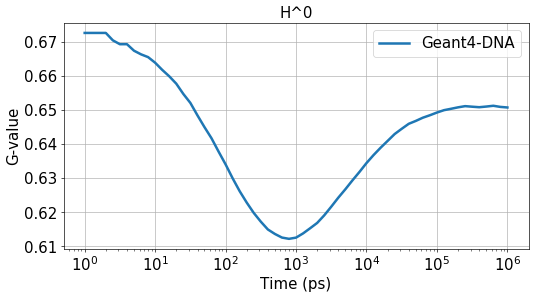

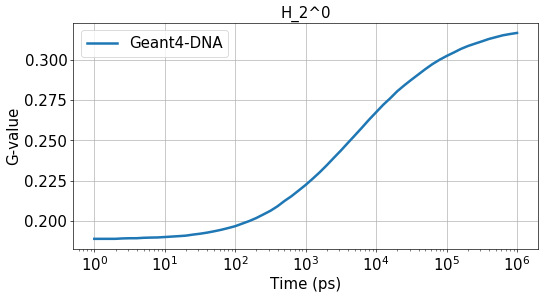

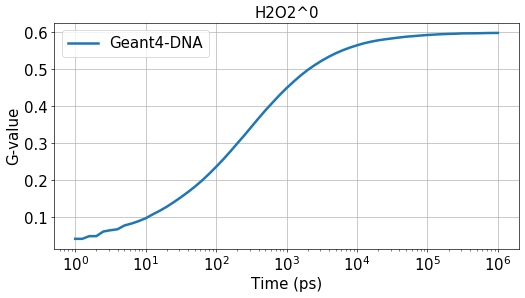

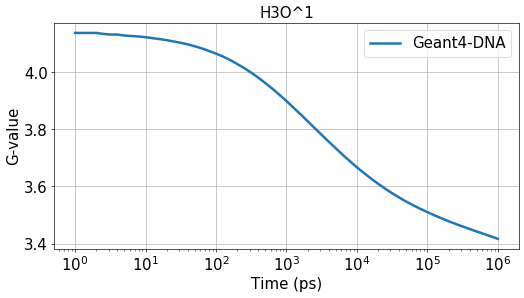

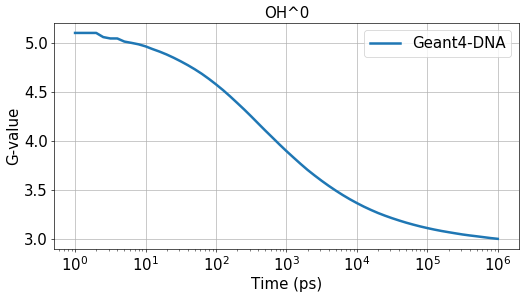

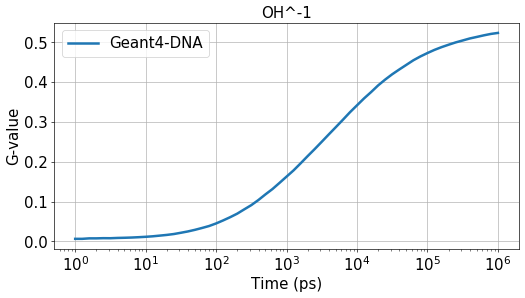

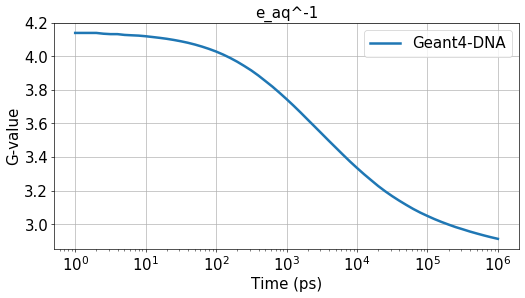

In [5]:
# make G-value plots
output = {"time": df['Time_ps'].values}
for x in df.columns:
    if x == 'Time_ps' or x == "None^0":
      continue
    plot(df['Time_ps'], df[x], x)
    output[label[x]] = df[x].values

# make data frame with Pandas and save as pickle file
pd.DataFrame.from_dict(output).to_pickle(OUTPUT_FILE)